# Exploratory Analysis of the Yaoundé Urban Expansion Dataset — Version 2

This notebook provides a reproducible exploration of the current
`yaounde_urban_expansion_30m_v2` release.

It is designed to answer four practical questions:

1. **What does the dataset contain?**
2. **Where and when did built-up expansion occur?**
3. **How reliable and spatially complete are the observations?**
4. **Which predictors appear most informative for future modelling?**

The current mapping method is **NDBI**, with the status:

```text
PROVISIONAL_PENDING_MANUAL_VALIDATION
```

The notebook therefore describes the released Version 1 dataset without
claiming that NDBI has already been confirmed by expert annotation.

## Main inputs

```text
data/final/yaounde_urban_expansion_30m_v2/
├── cell_time_dataset.parquet
├── historical_demand.csv
├── urban_sprawl_metrics.csv
├── primary_feature_schema.yaml
├── data_dictionary.yaml
└── dataset_card.md

data/metadata/final_dataset/
├── raster_output_manifest.csv
├── final_dataset_version.json
└── checksums.sha256
```

Some spatial figures use Earth Engine assets referenced by the raster output
manifest. All tabular analyses use the released local files.

## 1. Environment and notebook options

The core tabular analysis requires:

```text
pandas, numpy, matplotlib, pyarrow, pyyaml
```

Spatial and interactive sections additionally use, when available:

```text
earthengine-api, requests, Pillow, folium, plotly, scikit-learn, ipywidgets
```

Install missing optional packages in the active notebook environment with:

```python
# %pip install earthengine-api requests pillow folium plotly scikit-learn ipywidgets
```

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
import yaml

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

OPTIONAL_IMPORTS: dict[str, bool] = {}

try:
    import ee
    OPTIONAL_IMPORTS["earthengine-api"] = True
except ImportError:
    ee = None
    OPTIONAL_IMPORTS["earthengine-api"] = False

try:
    import requests
    from PIL import Image
    from io import BytesIO
    OPTIONAL_IMPORTS["requests+pillow"] = True
except ImportError:
    requests = None
    Image = None
    BytesIO = None
    OPTIONAL_IMPORTS["requests+pillow"] = False

try:
    import folium
    OPTIONAL_IMPORTS["folium"] = True
except ImportError:
    folium = None
    OPTIONAL_IMPORTS["folium"] = False

try:
    import plotly.express as px
    import plotly.graph_objects as go
    OPTIONAL_IMPORTS["plotly"] = True
except ImportError:
    px = None
    go = None
    OPTIONAL_IMPORTS["plotly"] = False

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    OPTIONAL_IMPORTS["scikit-learn"] = True
except ImportError:
    RandomForestClassifier = None
    roc_auc_score = None
    OPTIONAL_IMPORTS["scikit-learn"] = False

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    OPTIONAL_IMPORTS["ipywidgets"] = True
except ImportError:
    widgets = None
    display = None
    clear_output = None
    OPTIONAL_IMPORTS["ipywidgets"] = False

OPTIONAL_IMPORTS

{'earthengine-api': True,
 'requests+pillow': True,
 'folium': True,
 'plotly': True,
 'scikit-learn': True,
 'ipywidgets': True}

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root containing configs/final_dataset.yaml."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "configs/final_dataset.yaml").is_file():
            return candidate

    raise FileNotFoundError(
        "Could not find configs/final_dataset.yaml. "
        "Run the notebook from the SprawlGP repository."
    )


PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT  / "configs/final_dataset.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as stream:
    CONFIG = yaml.safe_load(stream)

FINAL_DIR = PROJECT_ROOT / CONFIG["outputs"]["final_directory"]
METADATA_DIR = PROJECT_ROOT / CONFIG["metadata"]["directory"]

PATHS = {
    "cell_time": FINAL_DIR / CONFIG["outputs"]["cell_time_dataset"],
    "demand": FINAL_DIR / CONFIG["outputs"]["historical_demand"],
    "metrics": FINAL_DIR / CONFIG["outputs"]["urban_sprawl_metrics"],
    "feature_schema": FINAL_DIR / CONFIG["outputs"]["primary_feature_schema"],
    "data_dictionary": FINAL_DIR / CONFIG["outputs"]["data_dictionary"],
    "dataset_card": FINAL_DIR / CONFIG["outputs"]["dataset_card"],
    "raster_manifest": (
        METADATA_DIR / CONFIG["metadata"]["raster_output_manifest"]
    ),
    "release_version": (
        METADATA_DIR / CONFIG["metadata"]["final_dataset_version"]
    ),
    "checksums": METADATA_DIR / CONFIG["metadata"]["checksums"],
    "thresholds": (
        PROJECT_ROOT
        / "data/metadata/built_up_candidates/threshold_table.csv"
    ),
    "candidate_gallery": (
        PROJECT_ROOT
        / "reports/built_up_candidates/02_candidate_map_gallery.png"
    ),
}

FIGURE_DIR = PROJECT_ROOT / "reports/exploration_v2/figures"
REPORT_DIR = PROJECT_ROOT / "reports/exploration_v2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, FINAL_DIR

(PosixPath('/Users/omer/Documents/MIORPA/Pending.../SprawlGP'),
 PosixPath('/Users/omer/Documents/MIORPA/Pending.../SprawlGP/data/final/yaounde_urban_expansion_30m_v2'))

## 2. Load and validate the released files

The notebook stops immediately if one of the three core analytical tables is
missing. Optional metadata files are loaded only when available.

In [3]:
from pathlib import Path
path = Path("../data/final/yaounde_urban_expansion_30m_v2/cell_time_dataset.parquet")
print(path.exists())  # Must return True

True


In [4]:
!pip install pyarrow


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [5]:
CORE_FILES = ["cell_time", "demand", "metrics"]
missing_core = [
    name for name in CORE_FILES
    if not PATHS[name].is_file()
]

if missing_core:
    raise FileNotFoundError(
        "Missing required Version 1 outputs: "
        + ", ".join(missing_core)
    )

cell_time = pd.read_parquet(PATHS["cell_time"])
demand = pd.read_csv(PATHS["demand"])
metrics = pd.read_csv(PATHS["metrics"])

feature_schema = (
    yaml.safe_load(PATHS["feature_schema"].read_text(encoding="utf-8"))
    if PATHS["feature_schema"].is_file()
    else {}
)
data_dictionary = (
    yaml.safe_load(PATHS["data_dictionary"].read_text(encoding="utf-8"))
    if PATHS["data_dictionary"].is_file()
    else {}
)
release_version = (
    json.loads(PATHS["release_version"].read_text(encoding="utf-8"))
    if PATHS["release_version"].is_file()
    else {}
)
raster_manifest = (
    pd.read_csv(PATHS["raster_manifest"])
    if PATHS["raster_manifest"].is_file()
    else pd.DataFrame()
)
thresholds = (
    pd.read_csv(PATHS["thresholds"])
    if PATHS["thresholds"].is_file()
    else pd.DataFrame()
)

print(f"Cell-time rows: {len(cell_time):,}")
print(f"Cell-time columns: {cell_time.shape[1]}")
print(f"Demand transitions: {len(demand)}")
print(f"Tracking epochs: {len(metrics)}")

Cell-time rows: 720,605
Cell-time columns: 41
Demand transitions: 5
Tracking epochs: 6


In [6]:
required_key_columns = {"cell_id", "forecast_origin", "target_year"}
missing_keys = required_key_columns.difference(cell_time.columns)

if missing_keys:
    raise ValueError(f"Missing key columns: {sorted(missing_keys)}")

duplicate_keys = int(
    cell_time.duplicated(["cell_id", "forecast_origin"]).sum()
)
invalid_horizon = int(
    (
        cell_time["target_year"].astype(int)
        != cell_time["forecast_origin"].astype(int) + 5
    ).sum()
)

release_checks = pd.Series(
    {
        "duplicate_cell_time_keys": duplicate_keys,
        "invalid_five_year_horizons": invalid_horizon,
        "binary_target": set(
            cell_time["target_transition_5y"].astype(int).unique()
        ).issubset({0, 1}),
        "all_rows_nonbuilt_at_origin": bool(
            (cell_time["built_state_final_t"].astype(int) == 0).all()
        ),
        "four_transition_origins": sorted(
            cell_time["forecast_origin"].astype(int).unique().tolist()
        ),
    },
    name="value",
)

release_checks

duplicate_cell_time_keys                                    0
invalid_five_year_horizons                                  0
binary_target                                            True
all_rows_nonbuilt_at_origin                              True
four_transition_origins        [2000, 2005, 2010, 2015, 2020]
Name: value, dtype: object

## 3. Dataset structure and release summary

The cell-time dataset contains one row for each cell that was:

- inside the reporting area;
- observed at both transition endpoints;
- non-built at the forecast origin;
- available with the required predictors.

It is therefore a **risk-set dataset**, not a full raster table containing
every built and non-built cell.

In [7]:
summary = pd.DataFrame(
    {
        "value": [
            release_version.get("dataset_id", CONFIG["release"]["dataset_id"]),
            release_version.get(
                "version",
                CONFIG["release"]["semantic_version"],
            ),
            CONFIG["release"]["release_status"],
            CONFIG["release"]["mapping_selection_status"],
            CONFIG["mapping"]["selected_index"],
            len(cell_time),
            cell_time["cell_id"].nunique(),
            len(demand),
            len(metrics),
        ]
    },
    index=[
        "dataset_id",
        "version",
        "release_status",
        "mapping_selection_status",
        "mapping_method",
        "cell_time_rows",
        "unique_cells",
        "transitions",
        "tracking_epochs",
    ],
)

summary

,value
dataset_id,yaounde_urban_expansion_30m_v2
version,2.0.0-provisional
release_status,FROZEN_PROVISIONAL_RELEASE
mapping_selection_status,PROVISIONAL_PENDING_MANUAL_VALIDATION
mapping_method,ndbi
cell_time_rows,720605
unique_cells,210842
transitions,5
tracking_epochs,6


In [8]:
transition_overview = (
    cell_time.groupby(
        [
            "transition_order",
            "transition_id",
            "forecast_origin",
            "target_year",
        ],
        as_index=False,
    )
    .agg(
        eligible_cells=("cell_id", "size"),
        converted_cells=("target_transition_5y", "sum"),
        mean_observation_count=(
            "valid_observation_count_t",
            "mean",
        ),
    )
)
transition_overview["conversion_fraction_5y"] = (
    transition_overview["converted_cells"]
    / transition_overview["eligible_cells"]
)
transition_overview["annualised_conversion_rate"] = (
    1
    - (
        1 - transition_overview["conversion_fraction_5y"]
    ) ** (1 / 5)
)

transition_overview

,transition_order,transition_id,forecast_origin,target_year,eligible_cells,converted_cells,mean_observation_count,conversion_fraction_5y,annualised_conversion_rate
0,0,2000_2005,2000,2005,197260,30314,1.470024,0.153675,0.032820
1,1,2005_2010,2005,2010,168945,33774,1.940182,0.199911,0.043626
2,2,2010_2015,2010,2015,140194,14414,2.990549,0.102815,0.021465
3,3,2015_2020,2015,2020,127706,44471,4.554790,0.348230,0.082050
4,4,2020_2025,2020,2025,86500,5314,6.577595,0.061434,0.012600


## 4. Temporal evolution of built-up form

All tracking metrics use the fixed all-epoch valid support. This makes the
series temporally comparable, although it may cover only a subset of the
administrative core.

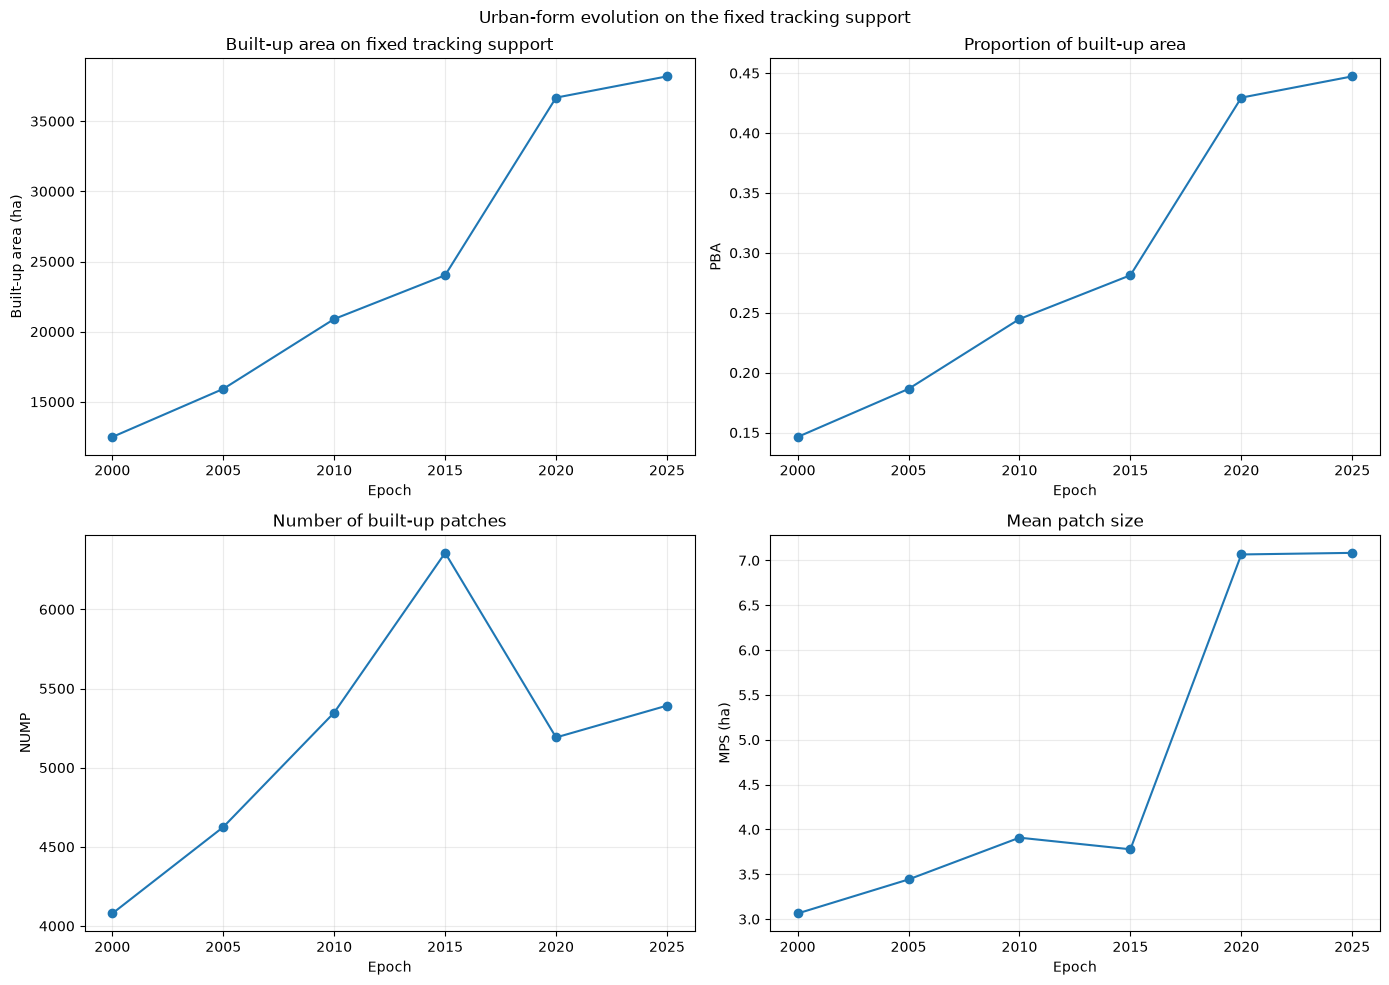

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    metrics["epoch"],
    metrics["built_area_ha"],
    marker="o",
)
axes[0, 0].set_title("Built-up area on fixed tracking support")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Built-up area (ha)")

axes[0, 1].plot(
    metrics["epoch"],
    metrics["pba"],
    marker="o",
)
axes[0, 1].set_title("Proportion of built-up area")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("PBA")

axes[1, 0].plot(
    metrics["epoch"],
    metrics["nump"],
    marker="o",
)
axes[1, 0].set_title("Number of built-up patches")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("NUMP")

axes[1, 1].plot(
    metrics["epoch"],
    metrics["mps_ha"],
    marker="o",
)
axes[1, 1].set_title("Mean patch size")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("MPS (ha)")

fig.suptitle("Urban-form evolution on the fixed tracking support")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "01_tracking_metrics.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

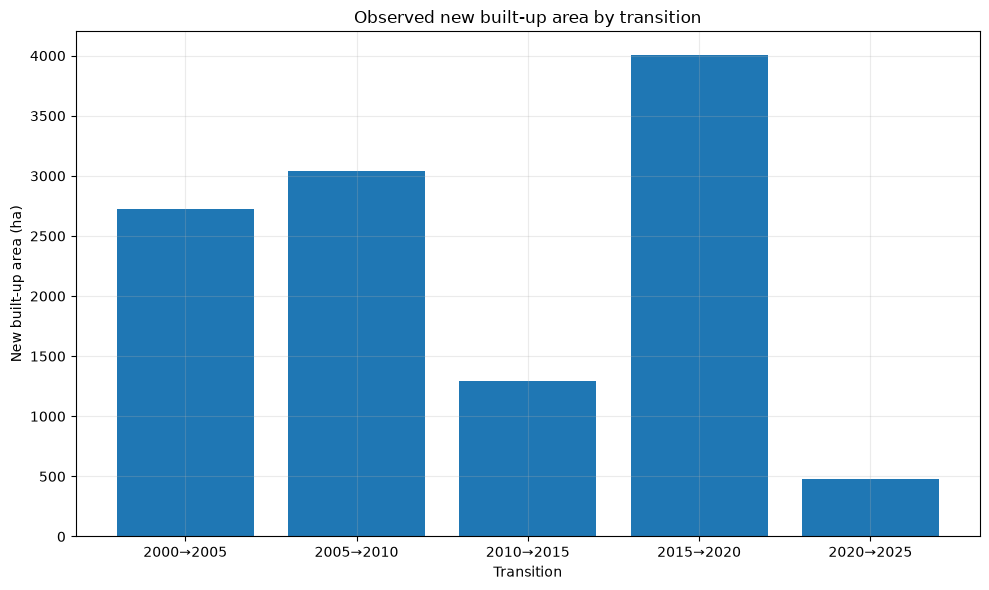

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = (
    demand["period_start"].astype(str)
    + "→"
    + demand["period_end"].astype(str)
)
ax.bar(labels, demand["observed_new_built_area_ha"])
ax.set_title("Observed new built-up area by transition")
ax.set_xlabel("Transition")
ax.set_ylabel("New built-up area (ha)")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_historical_demand.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

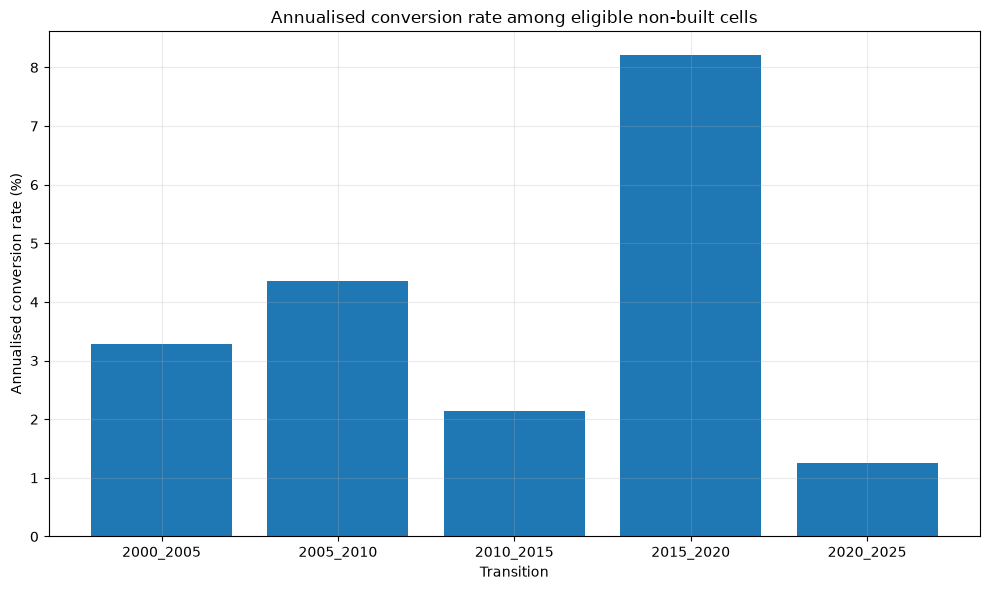

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = transition_overview["transition_id"]
values = (
    transition_overview["annualised_conversion_rate"] * 100
)
ax.bar(labels, values)
ax.set_title("Annualised conversion rate among eligible non-built cells")
ax.set_xlabel("Transition")
ax.set_ylabel("Annualised conversion rate (%)")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "03_annualised_conversion_rate.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Eligible-cell transition flow

The following Sankey diagram represents the **eligible non-built risk set**.
It does not include cells that were already built at the forecast origin.

In [12]:
if OPTIONAL_IMPORTS["plotly"]:
    source = []
    target = []
    value = []
    node_labels = []

    for _, row in transition_overview.iterrows():
        transition = str(row["transition_id"])
        start_index = len(node_labels)
        node_labels.extend(
            [
                f"{transition}: eligible non-built",
                f"{transition}: remained non-built",
                f"{transition}: converted",
            ]
        )
        source.extend([start_index, start_index])
        target.extend([start_index + 1, start_index + 2])
        value.extend(
            [
                int(row["eligible_cells"] - row["converted_cells"]),
                int(row["converted_cells"]),
            ]
        )

    figure = go.Figure(
        data=[
            go.Sankey(
                node={"label": node_labels},
                link={
                    "source": source,
                    "target": target,
                    "value": value,
                },
            )
        ]
    )
    figure.update_layout(
        title="Eligible-cell transition flows",
        height=650,
    )
    figure.show()
else:
    print("Plotly is not installed; the Sankey diagram was skipped.")

### Population and built-up growth

Version 1 stores population on each pairwise transition support and as an
origin-year predictor for eligible cells. It does **not** contain one
citywide population series measured on the fixed tracking support.

The notebook therefore compares transition-level population change with new
built-up area rather than constructing a potentially misleading citywide
population-density trend.

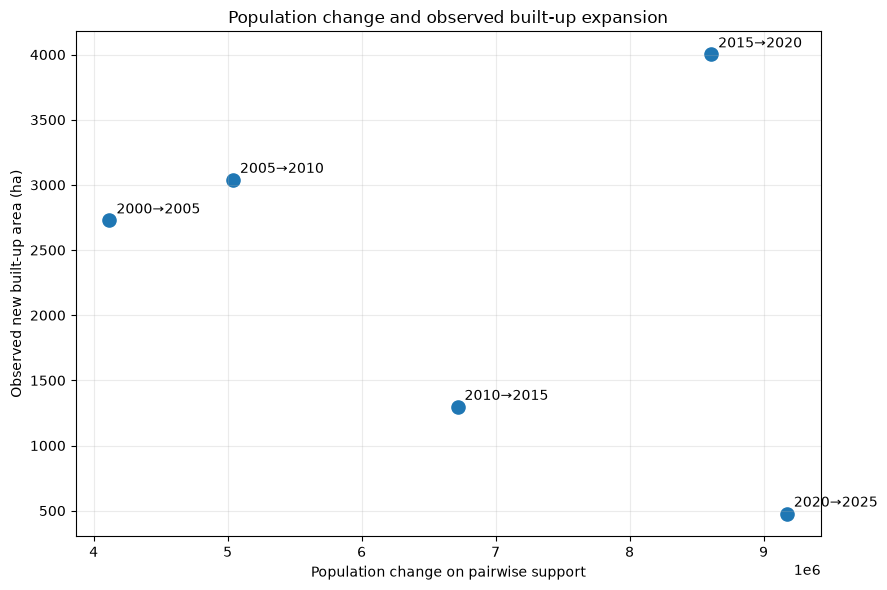

In [13]:
population_growth = demand[
    [
        "period_start",
        "period_end",
        "population_change",
        "observed_new_built_area_ha",
    ]
].copy()
population_growth["transition"] = (
    population_growth["period_start"].astype(str)
    + "→"
    + population_growth["period_end"].astype(str)
)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    population_growth["population_change"],
    population_growth["observed_new_built_area_ha"],
    s=90,
)
for row in population_growth.itertuples(index=False):
    ax.annotate(
        row.transition,
        (
            row.population_change,
            row.observed_new_built_area_ha,
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_title("Population change and observed built-up expansion")
ax.set_xlabel("Population change on pairwise support")
ax.set_ylabel("Observed new built-up area (ha)")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "04_population_vs_expansion.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 5. Otsu threshold stability

This section documents the temporal behaviour of the selected NDBI threshold.
Other indices are shown only when they are present in the existing threshold
table.

In [14]:
if thresholds.empty:
    print("The Otsu threshold table is unavailable.")
else:
    threshold_column = next(
        (
            column
            for column in [
                "threshold",
                "otsu_threshold",
                "threshold_value",
            ]
            if column in thresholds.columns
        ),
        None,
    )
    method_column = next(
        (
            column
            for column in ["method", "index", "candidate_method"]
            if column in thresholds.columns
        ),
        None,
    )
    epoch_column = next(
        (
            column
            for column in ["epoch", "year"]
            if column in thresholds.columns
        ),
        None,
    )

    if not all(
        [threshold_column, method_column, epoch_column]
    ):
        print(
            "Threshold table columns could not be identified:",
            thresholds.columns.tolist(),
        )
    else:
        plot_table = thresholds.copy()
        plot_table[method_column] = (
            plot_table[method_column].astype(str).str.lower()
        )
        selected_methods = [
            method
            for method in [
                "ndbi",
                "ibui",
                "ndbsui",
                "vbswir1_bi",
                "ibi",
            ]
            if method in set(plot_table[method_column])
        ]

        fig, ax = plt.subplots(figsize=(11, 6))
        for method in selected_methods:
            subset = plot_table[
                plot_table[method_column] == method
            ].sort_values(epoch_column)
            ax.plot(
                subset[epoch_column],
                subset[threshold_column],
                marker="o",
                label=method.upper(),
            )
        ax.set_title("Epoch-specific Otsu thresholds")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Threshold")
        ax.legend()
        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "05_otsu_thresholds.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()

Threshold table columns could not be identified: ['epoch', 'index_name', 'threshold_strategy', 'threshold_value', 'classification_direction', 'histogram_bucket_count', 'histogram_valid_pixel_count', 'histogram_min', 'histogram_max', 'histogram_mean', 'threshold_region', 'minimum_observation_count', 'status', 'failure_reason', 'source_composite_asset', 'source_count_asset', 'formula_version', 'grid_version', 'threshold_record_sha256', 'candidate_valid_pixel_count_core', 'candidate_built_pixel_count_core', 'candidate_nonbuilt_pixel_count_core', 'candidate_built_fraction_core', 'candidate_built_area_ha_core']


## 6. Data quality and spatial support

The first transition may contain substantially less valid spatial support
than later transitions. Every interpretation of demand and conversion must
therefore be read together with the support percentage.

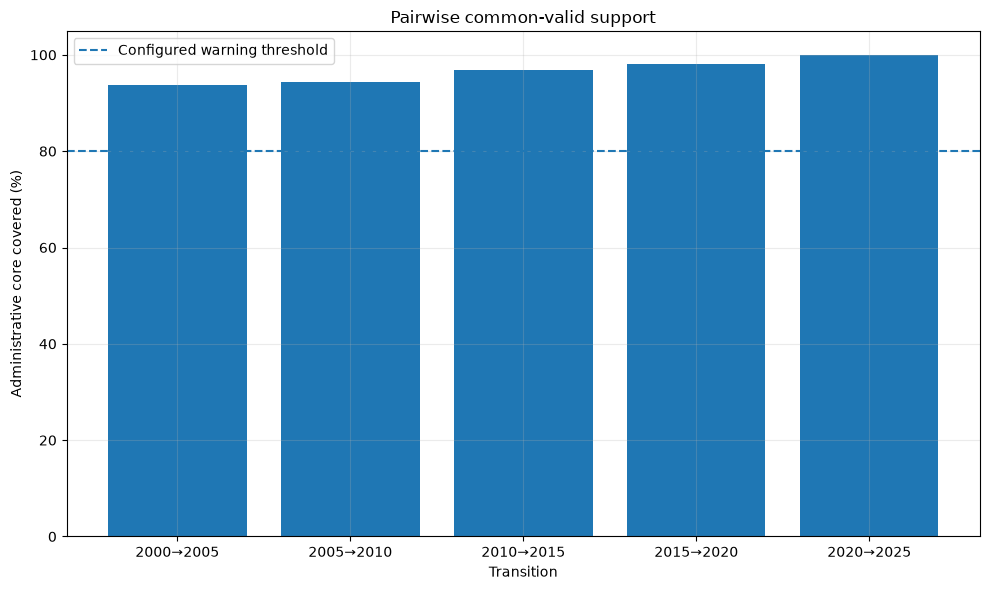

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = (
    demand["period_start"].astype(str)
    + "→"
    + demand["period_end"].astype(str)
)
ax.bar(labels, demand["common_valid_pct_of_core"])
ax.axhline(
    CONFIG["quality"]["pairwise_support_warning_pct"],
    linestyle="--",
    label="Configured warning threshold",
)
ax.set_title("Pairwise common-valid support")
ax.set_xlabel("Transition")
ax.set_ylabel("Administrative core covered (%)")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "06_pairwise_support.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

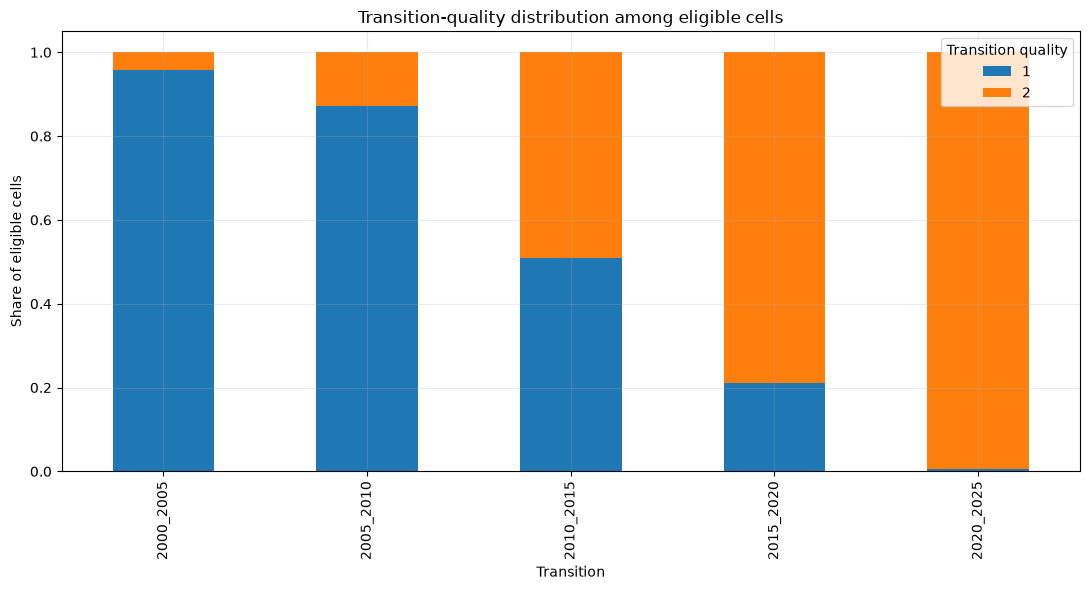

In [16]:
quality_counts = (
    cell_time.groupby(
        ["transition_id", "transition_quality"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "cells"})
)

quality_pivot = quality_counts.pivot(
    index="transition_id",
    columns="transition_quality",
    values="cells",
).fillna(0)

quality_share = quality_pivot.div(
    quality_pivot.sum(axis=1),
    axis=0,
)

quality_share.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
)
plt.title("Transition-quality distribution among eligible cells")
plt.xlabel("Transition")
plt.ylabel("Share of eligible cells")
plt.legend(title="Transition quality")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "07_transition_quality.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

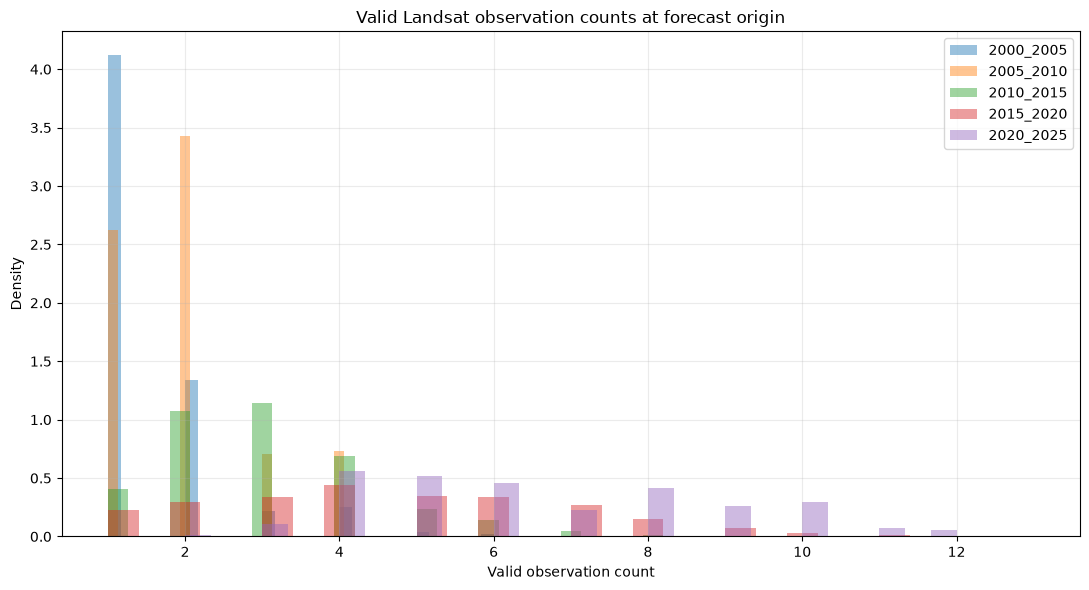

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

for transition, group in cell_time.groupby("transition_id"):
    values = group["valid_observation_count_t"].dropna().to_numpy()
    if len(values) > 100_000:
        rng = np.random.default_rng(20260730)
        values = rng.choice(values, size=100_000, replace=False)

    ax.hist(
        values,
        bins=30,
        alpha=0.45,
        density=True,
        label=str(transition),
    )

ax.set_title("Valid Landsat observation counts at forecast origin")
ax.set_xlabel("Valid observation count")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "08_observation_count_distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 7. Predictor distributions by outcome

The following figures compare cells that converted within five years with
cells that remained non-built. The comparison is descriptive and does not
establish causality.

To keep the plots responsive, the notebook uses a reproducible sample when
the dataset is large.

In [18]:
PREDICTOR_CANDIDATES = [
    "ndbi_t",
    "ibui_t",
    "ndbsui_t",
    "distance_to_built_m_t",
    "built_fraction_3x3_t",
    "built_fraction_11x11_t",
    "recent_local_growth_5y_t",
    "elevation_m",
    "slope_degrees",
    "population_density_t",
]

predictors = [
    column
    for column in PREDICTOR_CANDIDATES
    if column in cell_time.columns
]

MAX_EXPLORATORY_ROWS = 120_000
if len(cell_time) > MAX_EXPLORATORY_ROWS:
    exploratory = (
        cell_time.groupby(
            ["transition_id", "target_transition_5y"],
            group_keys=False,
        )
        .apply(
            lambda frame: frame.sample(
                min(
                    len(frame),
                    max(
                        1,
                        MAX_EXPLORATORY_ROWS
                        // (
                            cell_time["transition_id"].nunique()
                            * 2
                        ),
                    ),
                ),
                random_state=20260730,
            )
        )
        .reset_index(drop=True)
    )
else:
    exploratory = cell_time.copy()

print(f"Exploratory sample rows: {len(exploratory):,}")
predictors

Exploratory sample rows: 113,314


['ndbi_t',
 'ibui_t',
 'ndbsui_t',
 'distance_to_built_m_t',
 'built_fraction_3x3_t',
 'built_fraction_11x11_t',
 'recent_local_growth_5y_t',
 'elevation_m',
 'slope_degrees',
 'population_density_t']

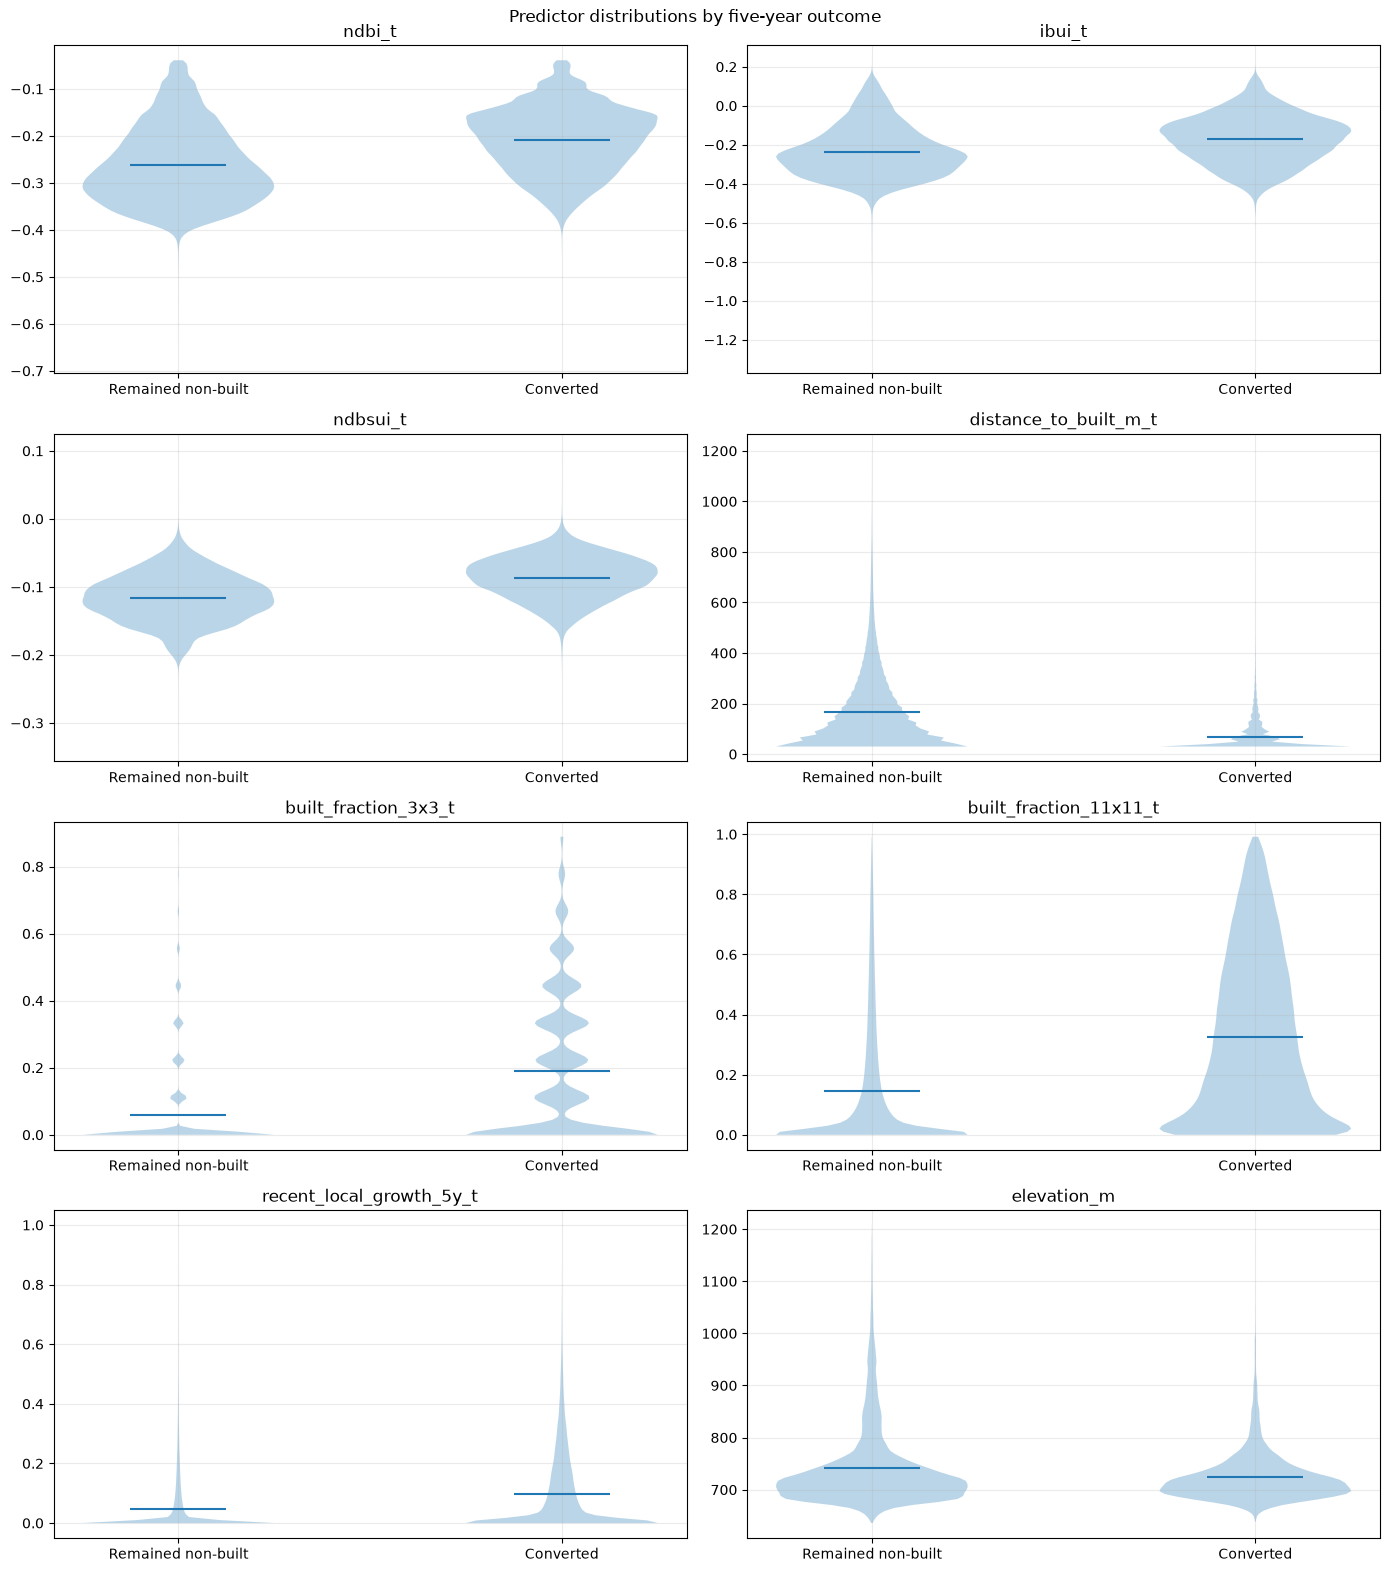

In [28]:
selected_violin_predictors = predictors[:8]
column_count = 2
row_count = math.ceil(len(selected_violin_predictors) / column_count)

fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(14, 4 * row_count),
)
axes = np.atleast_1d(axes).ravel()

for axis, predictor in zip(axes, selected_violin_predictors):
    nonconverted = exploratory.loc[
        exploratory["target_transition_5y"] == 0,
        predictor,
    ].dropna()
    converted = exploratory.loc[
        exploratory["target_transition_5y"] == 1,
        predictor,
    ].dropna()

    axis.violinplot(
        [nonconverted, converted],
        showmeans=True,
        showextrema=False,
    )
    axis.set_xticks([1, 2])
    axis.set_xticklabels(
        ["Remained non-built", "Converted"]
    )
    axis.set_title(predictor)

for axis in axes[len(selected_violin_predictors):]:
    axis.axis("off")

fig.suptitle("Predictor distributions by five-year outcome")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "09_predictor_violins.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 8. Predictor correlation and redundancy

The heatmap uses a sampled table and Pearson correlation. It is intended to
identify potentially redundant inputs before model preprocessing.

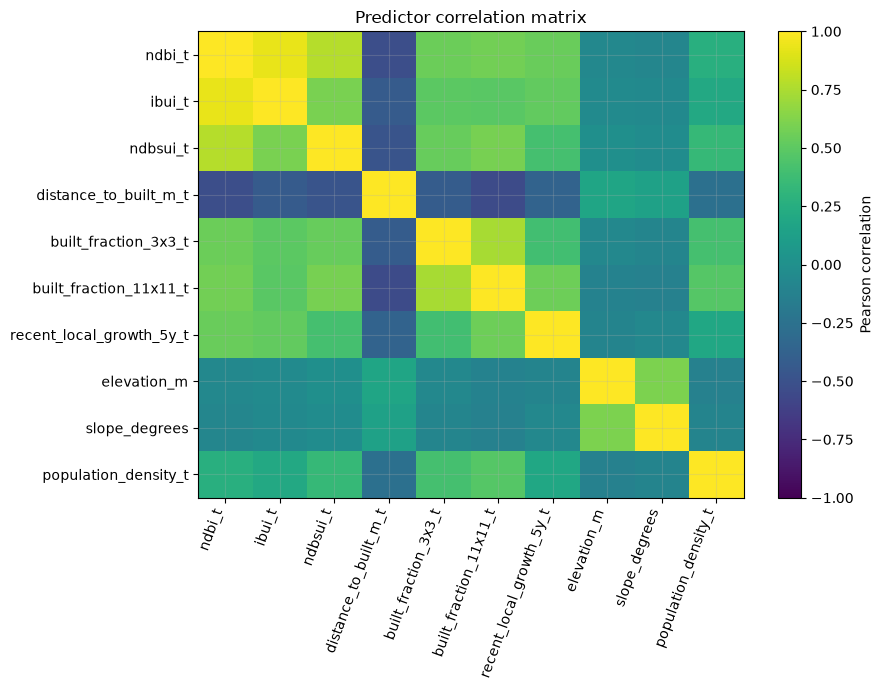

In [29]:
correlation_columns = [
    column
    for column in predictors
    if pd.api.types.is_numeric_dtype(exploratory[column])
]

correlation = (
    exploratory[correlation_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .corr()
)

fig, ax = plt.subplots(
    figsize=(
        max(9, len(correlation_columns) * 0.8),
        max(7, len(correlation_columns) * 0.7),
    )
)
image = ax.imshow(
    correlation.to_numpy(),
    vmin=-1,
    vmax=1,
    aspect="auto",
)
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(
    correlation.columns,
    rotation=70,
    ha="right",
)
ax.set_yticklabels(correlation.index)
ax.set_title("Predictor correlation matrix")
fig.colorbar(image, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "10_predictor_correlation.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 9. Interactive three-dimensional feature view

This optional Plotly figure uses:

- X: distance to existing built-up land;
- Y: elevation;
- Z: NDBI;
- colour: five-year conversion outcome.

The displayed points are sampled for browser performance.

In [30]:
if OPTIONAL_IMPORTS["plotly"]:
    required_3d = {
        "distance_to_built_m_t",
        "elevation_m",
        "ndbi_t",
        "target_transition_5y",
    }
    if required_3d.issubset(exploratory.columns):
        plot_3d = exploratory[
            list(required_3d)
        ].dropna()

        if len(plot_3d) > 20_000:
            plot_3d = plot_3d.sample(
                20_000,
                random_state=20260730,
            )

        plot_3d["outcome"] = plot_3d[
            "target_transition_5y"
        ].map(
            {
                0: "Remained non-built",
                1: "Converted",
            }
        )

        figure = px.scatter_3d(
            plot_3d,
            x="distance_to_built_m_t",
            y="elevation_m",
            z="ndbi_t",
            color="outcome",
            opacity=0.55,
            title="Exploratory feature space",
        )
        figure.show()
    else:
        print("Required columns for the 3D view are unavailable.")
else:
    print("Plotly is not installed; the 3D view was skipped.")

## 10. Exploratory predictor importance

This is an optional diagnostic model, not the final forecasting model.

The Random Forest is trained on the first three transitions and evaluated on
the 2020→2025 transition. Feature importance is descriptive and must not be
interpreted as a causal effect.

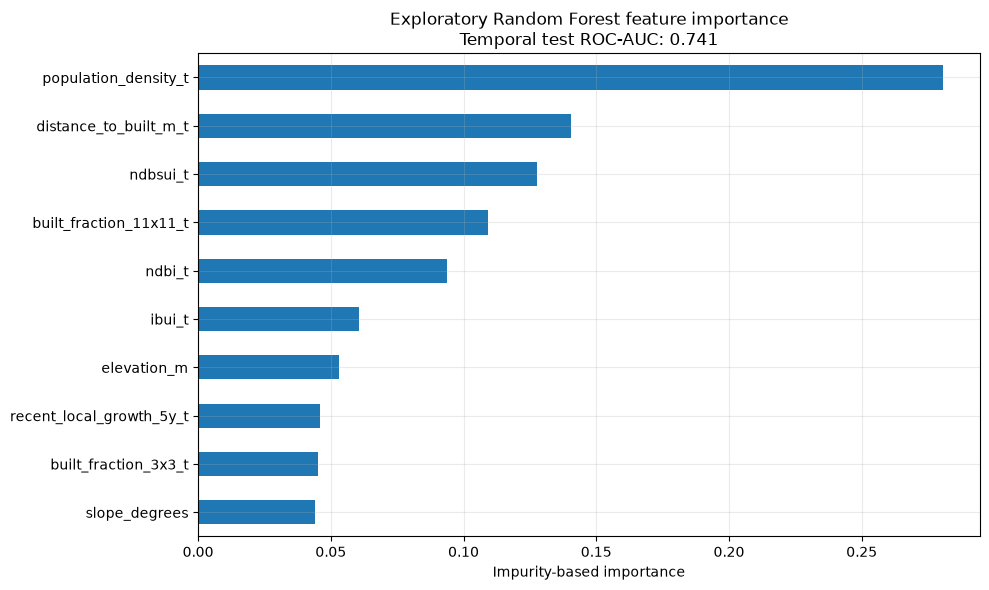

In [31]:
if OPTIONAL_IMPORTS["scikit-learn"]:
    model_features = [
        column
        for column in predictors
        if column not in {
            "recent_local_growth_available_t",
        }
    ]

    train = cell_time[
        cell_time["forecast_origin"].astype(int) < 2020
    ].copy()
    test = cell_time[
        cell_time["forecast_origin"].astype(int) == 2020
    ].copy()

    train = train[
        model_features + ["target_transition_5y"]
    ].replace([np.inf, -np.inf], np.nan).dropna()
    test = test[
        model_features + ["target_transition_5y"]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    if len(train) > 150_000:
        train = train.sample(
            150_000,
            random_state=20260730,
        )
    if len(test) > 80_000:
        test = test.sample(
            80_000,
            random_state=20260730,
        )

    if train["target_transition_5y"].nunique() == 2:
        forest = RandomForestClassifier(
            n_estimators=250,
            max_depth=14,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            random_state=20260730,
            n_jobs=-1,
        )
        forest.fit(
            train[model_features],
            train["target_transition_5y"],
        )

        importance = pd.Series(
            forest.feature_importances_,
            index=model_features,
        ).sort_values(ascending=True)

        probabilities = forest.predict_proba(
            test[model_features]
        )[:, 1]
        temporal_auc = roc_auc_score(
            test["target_transition_5y"],
            probabilities,
        )

        fig, ax = plt.subplots(
            figsize=(10, max(6, len(importance) * 0.35))
        )
        importance.plot(kind="barh", ax=ax)
        ax.set_title(
            "Exploratory Random Forest feature importance\n"
            f"Temporal test ROC-AUC: {temporal_auc:.3f}"
        )
        ax.set_xlabel("Impurity-based importance")
        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "11_exploratory_feature_importance.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()
    else:
        print("The training sample does not contain both classes.")
else:
    print(
        "Scikit-learn is not installed; "
        "feature importance was skipped."
    )

## 11. Spatial exploration from the released cell-time table

The following maps use only the local Parquet file. They represent eligible
cells for a selected transition, not every cell in the city.

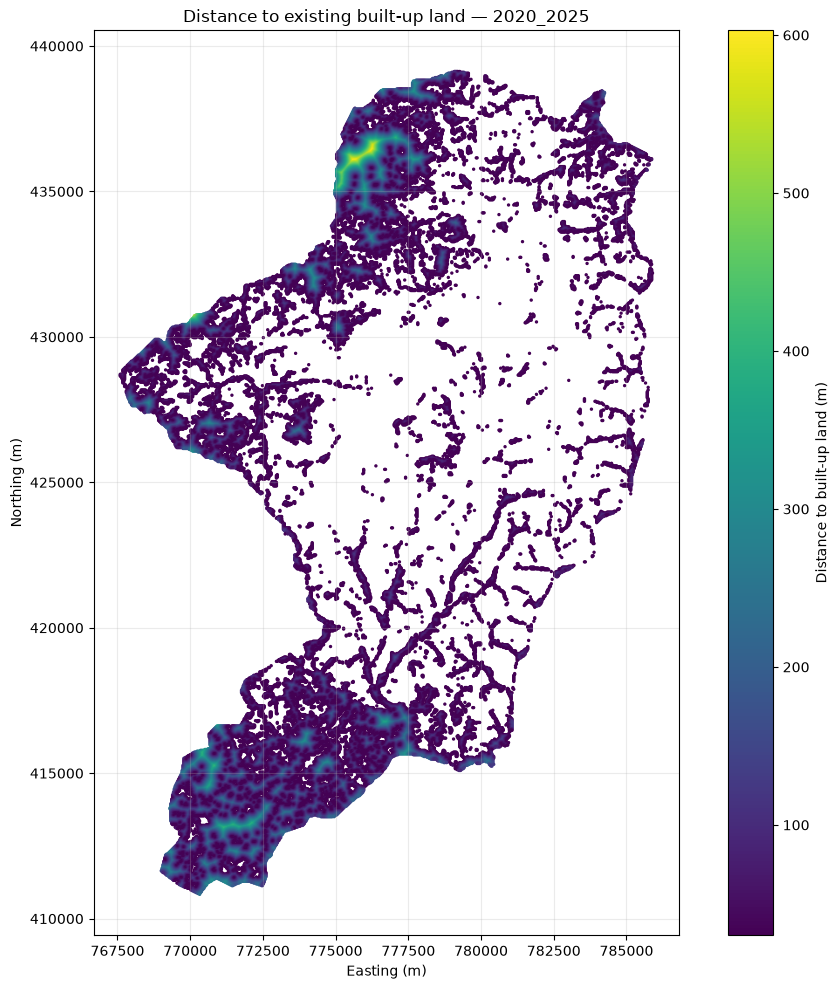

In [32]:
LATEST_TRANSITION = str(
    transition_overview.sort_values(
        "forecast_origin"
    ).iloc[-1]["transition_id"]
)
latest_cells = cell_time[
    cell_time["transition_id"].astype(str) == LATEST_TRANSITION
].copy()

MAX_MAP_POINTS = 120_000
if len(latest_cells) > MAX_MAP_POINTS:
    latest_map_sample = latest_cells.sample(
        MAX_MAP_POINTS,
        random_state=20260730,
    )
else:
    latest_map_sample = latest_cells

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    latest_map_sample["x_center_m"],
    latest_map_sample["y_center_m"],
    c=latest_map_sample["distance_to_built_m_t"],
    s=2,
)
ax.set_aspect("equal")
ax.set_title(
    f"Distance to existing built-up land — {LATEST_TRANSITION}"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
fig.colorbar(
    scatter,
    ax=ax,
    label="Distance to built-up land (m)",
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "12_distance_to_built_map.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

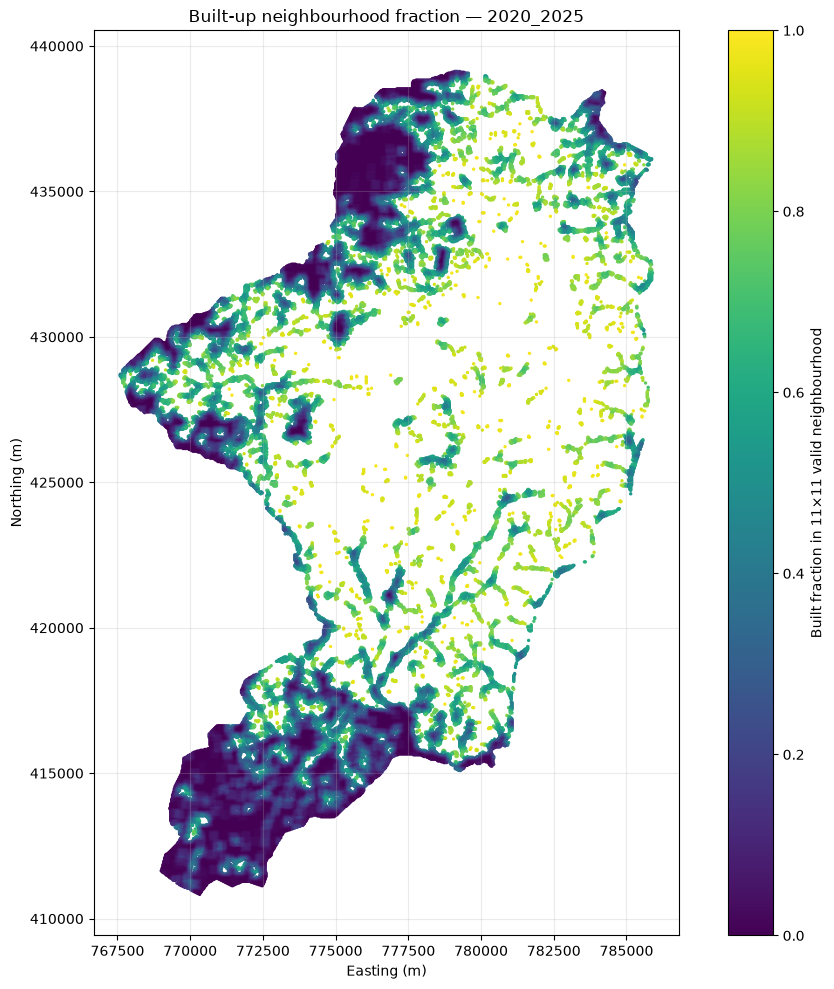

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    latest_map_sample["x_center_m"],
    latest_map_sample["y_center_m"],
    c=latest_map_sample["built_fraction_11x11_t"],
    s=2,
    vmin=0,
    vmax=1,
)
ax.set_aspect("equal")
ax.set_title(
    f"Built-up neighbourhood fraction — {LATEST_TRANSITION}"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
fig.colorbar(
    scatter,
    ax=ax,
    label="Built fraction in 11×11 valid neighbourhood",
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "13_neighbourhood_density_map.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

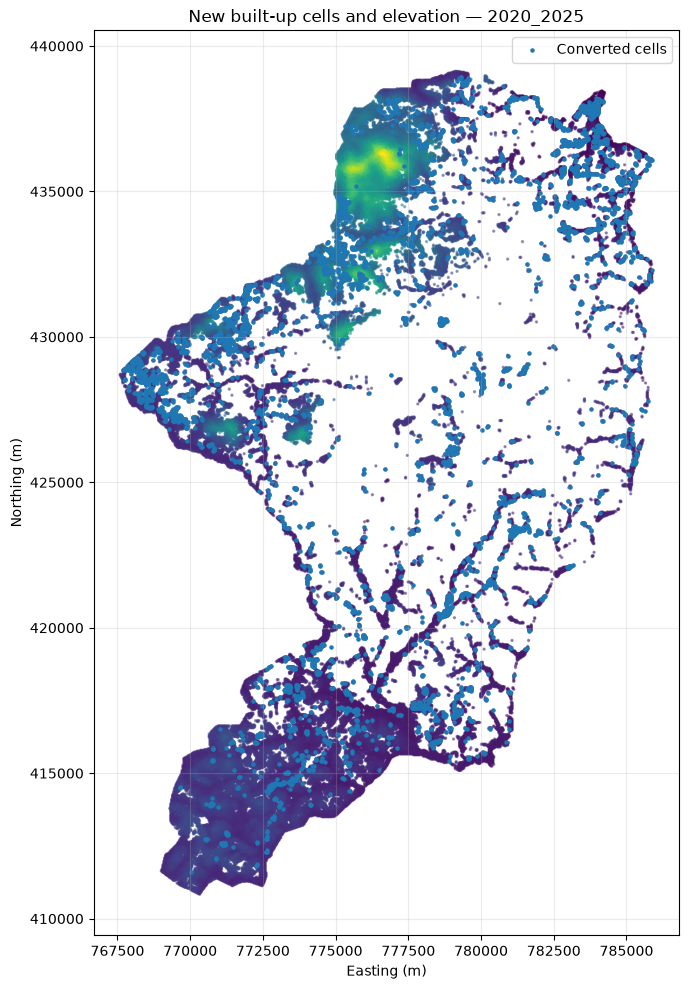

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

background = latest_map_sample.sample(
    min(len(latest_map_sample), 80_000),
    random_state=20260730,
)
converted = latest_cells[
    latest_cells["target_transition_5y"].astype(int) == 1
]

ax.scatter(
    background["x_center_m"],
    background["y_center_m"],
    c=background["elevation_m"],
    s=2,
    alpha=0.45,
)
ax.scatter(
    converted["x_center_m"],
    converted["y_center_m"],
    s=5,
    label="Converted cells",
)
ax.set_aspect("equal")
ax.set_title(
    f"New built-up cells and elevation — {LATEST_TRANSITION}"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "14_expansion_and_elevation.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Detailed 30 m grid view

The detailed view automatically centres on a converted cell in the latest
transition and displays individual 30 m cells within a local window.

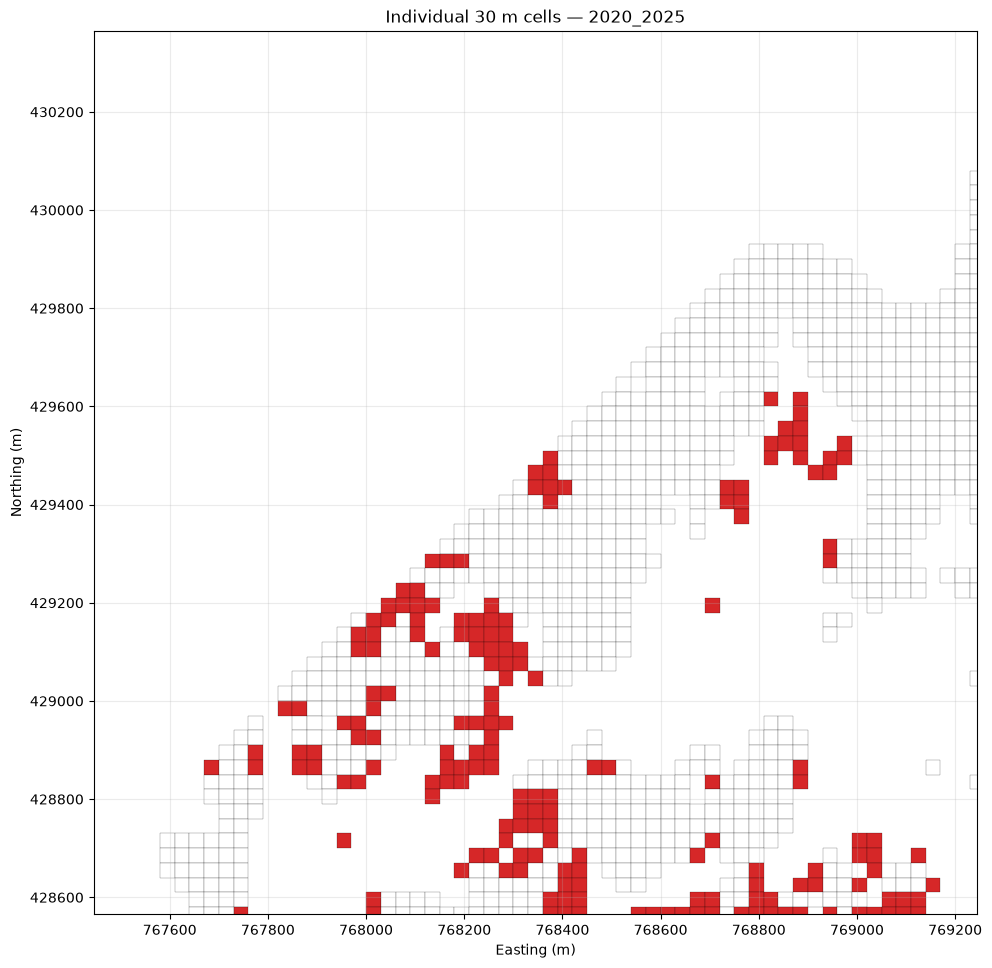

In [35]:
positive_latest = latest_cells[
    latest_cells["target_transition_5y"].astype(int) == 1
]

if positive_latest.empty:
    print("No positive cells are available for the detailed grid view.")
else:
    centre = positive_latest.iloc[len(positive_latest) // 2]
    radius_m = 900

    window = latest_cells[
        latest_cells["x_center_m"].between(
            centre["x_center_m"] - radius_m,
            centre["x_center_m"] + radius_m,
        )
        & latest_cells["y_center_m"].between(
            centre["y_center_m"] - radius_m,
            centre["y_center_m"] + radius_m,
        )
    ].copy()

    fig, ax = plt.subplots(figsize=(10, 10))
    for row in window.itertuples(index=False):
        rectangle = Rectangle(
            (
                float(row.x_center_m) - 15,
                float(row.y_center_m) - 15,
            ),
            30,
            30,
            facecolor=(
                "tab:red"
                if int(row.target_transition_5y) == 1
                else "white"
            ),
            edgecolor="black",
            linewidth=0.15,
        )
        ax.add_patch(rectangle)

    ax.set_xlim(
        centre["x_center_m"] - radius_m,
        centre["x_center_m"] + radius_m,
    )
    ax.set_ylim(
        centre["y_center_m"] - radius_m,
        centre["y_center_m"] + radius_m,
    )
    ax.set_aspect("equal")
    ax.set_title(
        f"Individual 30 m cells — {LATEST_TRANSITION}"
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "15_grid_30m_detail.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 12. Earth Engine spatial products

This section creates:

- a five-epoch final-state gallery;
- four transition maps;
- a first-built-year map;
- a valid-observation-count map;
- a tracking-support map;
- a terrain and expansion overlay.

It requires an authenticated Earth Engine session and the finalized raster
output manifest.

The notebook never modifies or exports Earth Engine assets.

In [36]:
EE_READY = False

if (
    OPTIONAL_IMPORTS["earthengine-api"]
    and OPTIONAL_IMPORTS["requests+pillow"]
    and not raster_manifest.empty
):
    try:
        ee.Initialize(
            project=CONFIG["project"]["earth_engine_project"]
        )
        EE_READY = True
        print("Earth Engine is ready.")
    except Exception as error:
        print(
            "Earth Engine could not be initialized. "
            "Authenticate locally and rerun this cell."
        )
        print(error)
else:
    print(
        "Earth Engine, requests/Pillow, or the raster manifest "
        "is unavailable. Spatial asset figures will be skipped."
    )

Earth Engine is ready.


In [37]:
def manifest_asset(
    product_type: str,
    *,
    epoch: int | None = None,
    period_start: int | None = None,
    period_end: int | None = None,
) -> str:
    """Return one Earth Engine asset ID from the raster manifest."""
    frame = raster_manifest[
        raster_manifest["product_type"].astype(str)
        == product_type
    ].copy()

    if epoch is not None and "epoch" in frame.columns:
        frame = frame[
            pd.to_numeric(
                frame["epoch"],
                errors="coerce",
            ) == epoch
        ]

    if (
        period_start is not None
        and "period_start" in frame.columns
    ):
        frame = frame[
            pd.to_numeric(
                frame["period_start"],
                errors="coerce",
            ) == period_start
        ]

    if period_end is not None and "period_end" in frame.columns:
        frame = frame[
            pd.to_numeric(
                frame["period_end"],
                errors="coerce",
            ) == period_end
        ]

    if len(frame) != 1:
        raise ValueError(
            f"Expected one {product_type} asset, found {len(frame)}."
        )

    return str(frame.iloc[0]["asset_id"])


def ee_thumbnail(
    image: Any,
    visualization: dict[str, Any],
    *,
    region: Any | None = None,
    dimensions: int = 800,
) -> Any:
    """Download one Earth Engine visualization as a Pillow image."""
    if not EE_READY:
        raise RuntimeError("Earth Engine is not ready.")

    if region is None:
        region = image.geometry()

    url = image.getThumbURL(
        {
            **visualization,
            "region": region,
            "dimensions": dimensions,
            "format": "png",
        }
    )
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    return Image.open(BytesIO(response.content))


def show_ee_gallery(
    images: list[tuple[str, Any, dict[str, Any]]],
    *,
    columns: int = 3,
    filename: str | None = None,
) -> None:
    """Display a gallery of Earth Engine thumbnails."""
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(5 * columns, 5 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for axis, (title, image, visualization) in zip(
        axes,
        images,
    ):
        thumbnail = ee_thumbnail(image, visualization)
        axis.imshow(thumbnail)
        axis.set_title(title)
        axis.axis("off")

    for axis in axes[len(images):]:
        axis.axis("off")

    fig.tight_layout()

    if filename:
        fig.savefig(
            FIGURE_DIR / filename,
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()

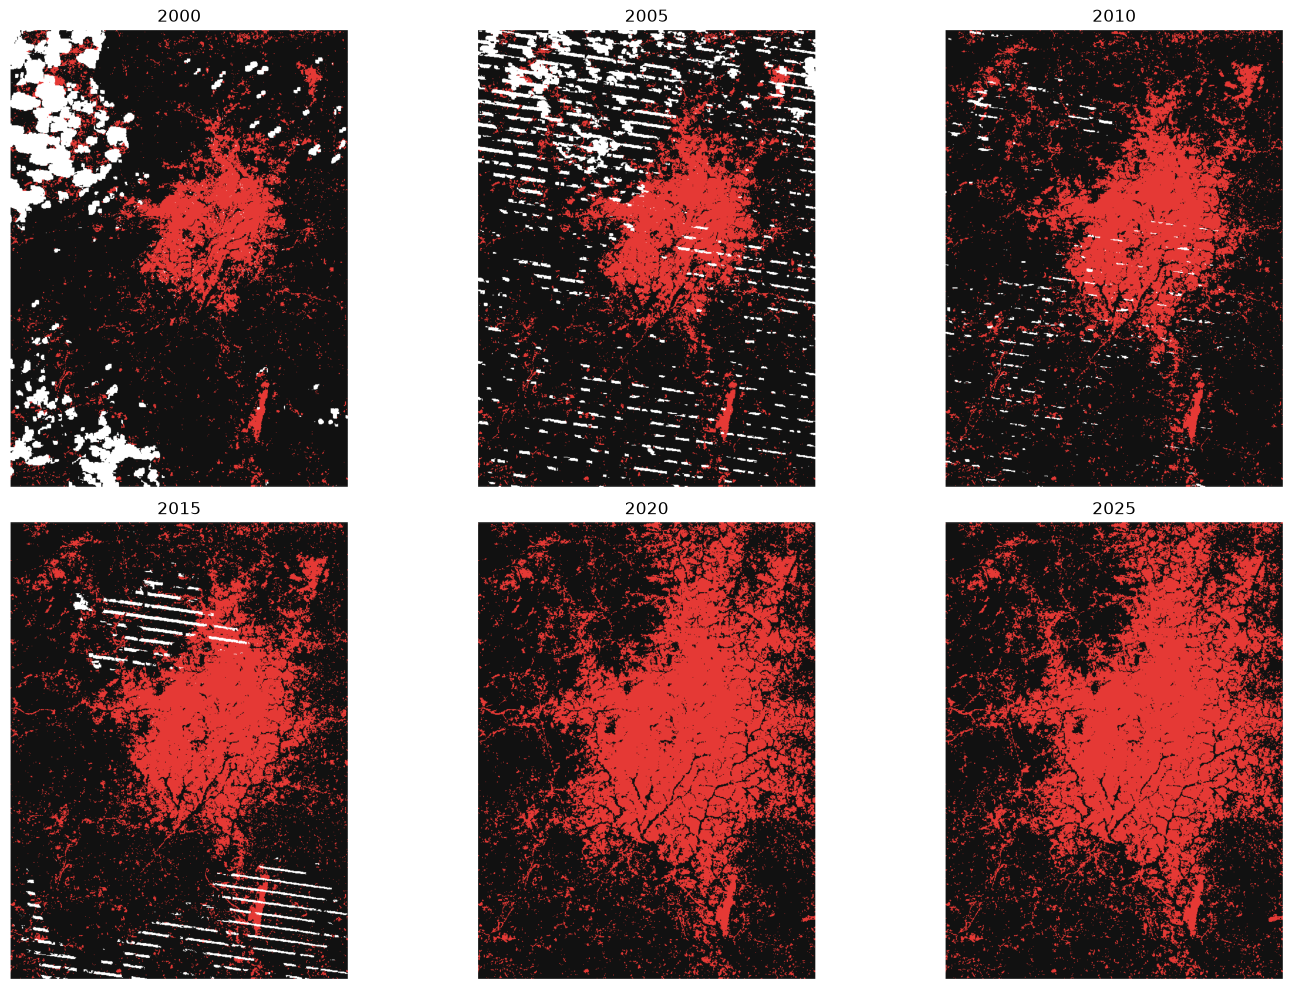

In [38]:
if EE_READY:
    state_gallery = []

    for epoch in CONFIG["mapping"]["epochs"]:
        asset_id = manifest_asset("state", epoch=int(epoch))
        image = ee.Image(asset_id).select("built_state_final")
        state_gallery.append(
            (
                str(epoch),
                image,
                {
                    "min": 0,
                    "max": 1,
                    "palette": ["111111", "e53935"],
                },
            )
        )

    show_ee_gallery(
        state_gallery,
        columns=3,
        filename="16_final_state_gallery.png",
    )

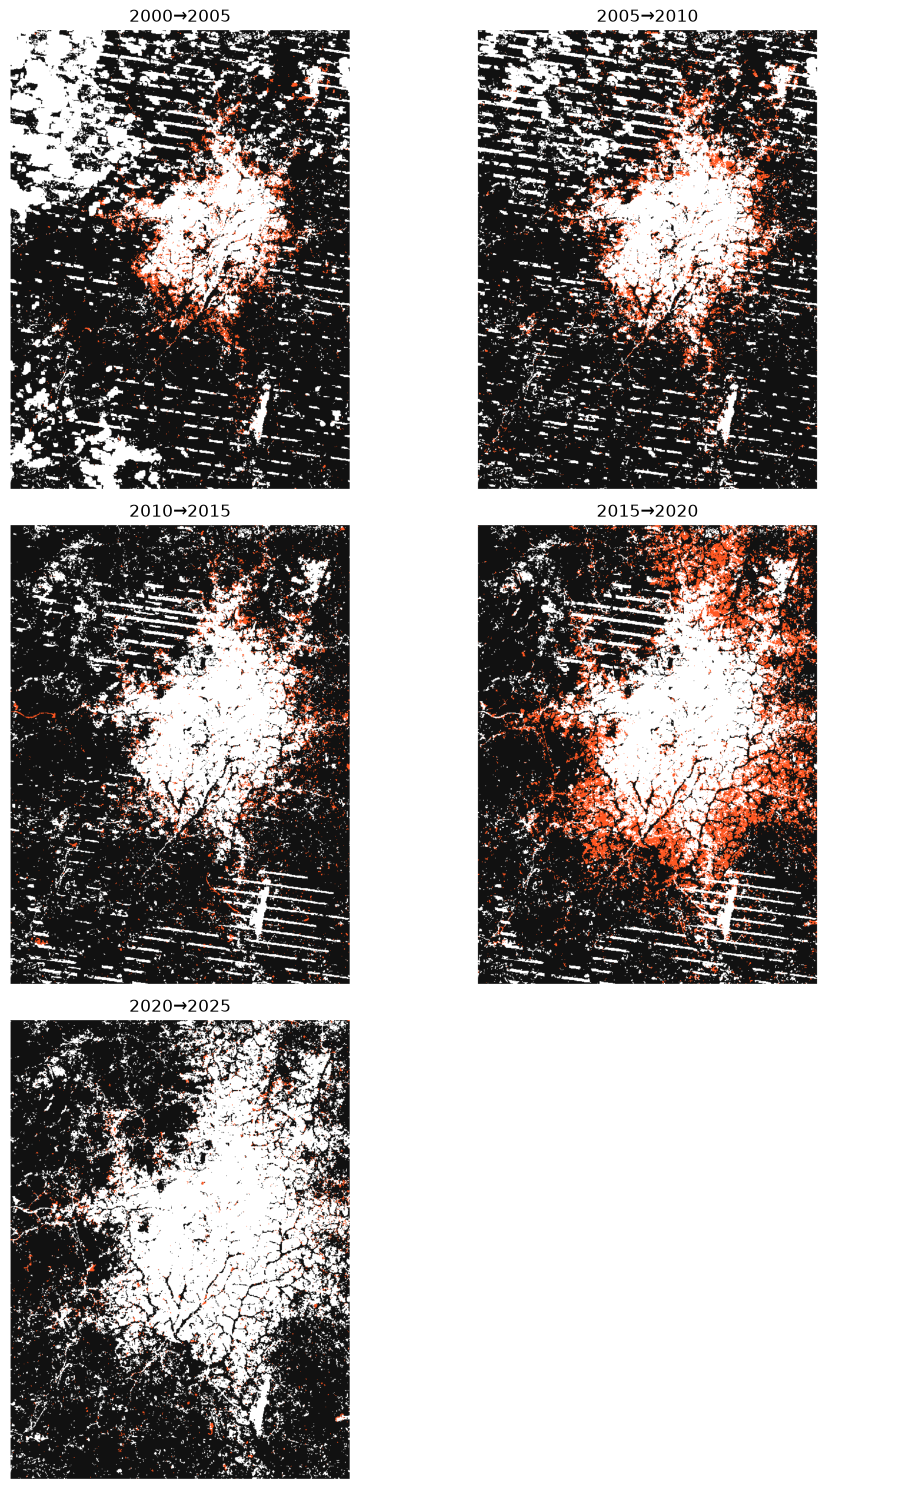

In [39]:
if EE_READY:
    transition_gallery = []

    for start, end in zip(
        CONFIG["mapping"]["epochs"][:-1],
        CONFIG["mapping"]["epochs"][1:],
    ):
        asset_id = manifest_asset(
            "transition",
            period_start=int(start),
            period_end=int(end),
        )
        image = ee.Image(asset_id).select(
            "target_transition_5y"
        )
        transition_gallery.append(
            (
                f"{start}→{end}",
                image,
                {
                    "min": 0,
                    "max": 1,
                    "palette": ["111111", "ff5722"],
                },
            )
        )

    show_ee_gallery(
        transition_gallery,
        columns=2,
        filename="17_transition_gallery.png",
    )

In [40]:
if EE_READY:
    first_built_year = ee.Image.constant(0).toInt16()

    for epoch in CONFIG["mapping"]["epochs"]:
        state = ee.Image(
            manifest_asset("state", epoch=int(epoch))
        ).select("built_state_final")
        first_built_year = first_built_year.where(
            first_built_year.eq(0).And(state.eq(1)),
            int(epoch),
        )

    first_built_year = first_built_year.updateMask(
        first_built_year.gt(0)
    )

    first_year_thumbnail = ee_thumbnail(
        first_built_year,
        {
            "min": min(CONFIG["mapping"]["epochs"]),
            "max": max(CONFIG["mapping"]["epochs"]),
            "palette": [
                "313695",
                "4575b4",
                "74add1",
                "fdae61",
                "d73027",
            ],
        },
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(first_year_thumbnail)
    ax.set_title("First observed built-up epoch")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "18_first_built_year.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

EEException: Image.clipToBoundsAndScale: The geometry for image clipping must be bounded.

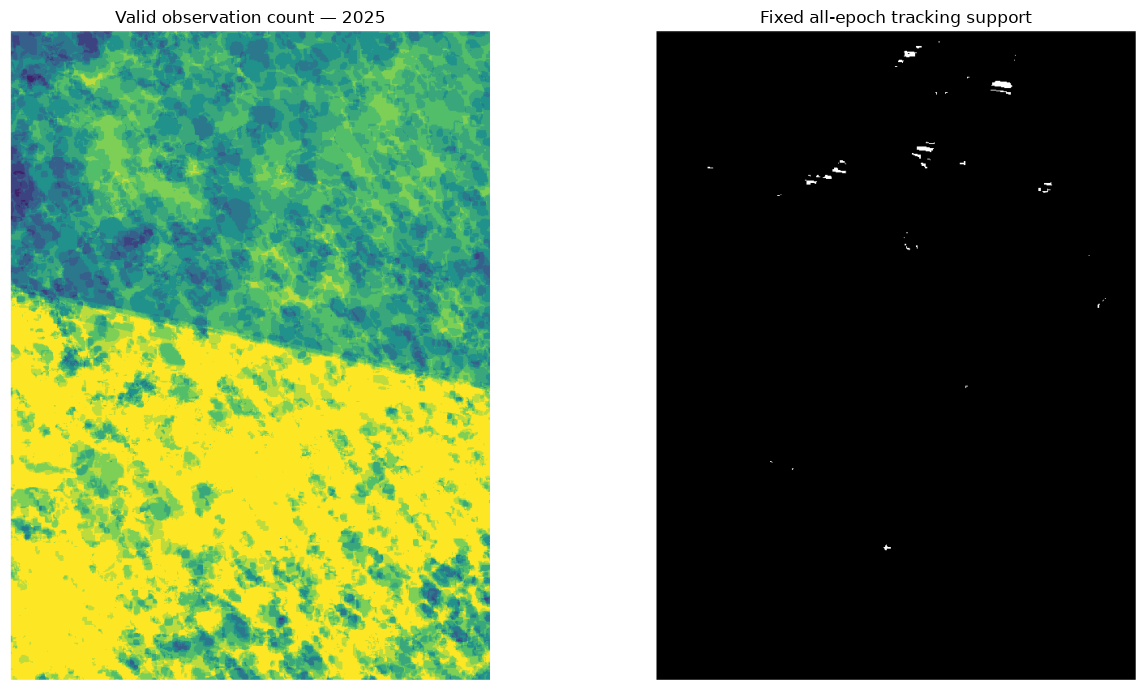

In [ ]:
if EE_READY:
    latest_epoch = max(CONFIG["mapping"]["epochs"])
    latest_state = ee.Image(
        manifest_asset("state", epoch=int(latest_epoch))
    )

    quality_image = latest_state.select(
        "valid_observation_count"
    )
    quality_thumbnail = ee_thumbnail(
        quality_image,
        {
            "min": 0,
            "max": 10,
            "palette": [
                "440154",
                "3b528b",
                "21918c",
                "5ec962",
                "fde725",
            ],
        },
    )

    support_asset = manifest_asset("tracking_support")
    support_image = ee.Image(support_asset).select(
        "tracking_common_support"
    )
    support_thumbnail = ee_thumbnail(
        support_image,
        {
            "min": 0,
            "max": 1,
            "palette": ["000000", "ffffff"],
        },
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(quality_thumbnail)
    axes[0].set_title(
        f"Valid observation count — {latest_epoch}"
    )
    axes[0].axis("off")

    axes[1].imshow(support_thumbnail)
    axes[1].set_title("Fixed all-epoch tracking support")
    axes[1].axis("off")

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "19_quality_and_tracking_support.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

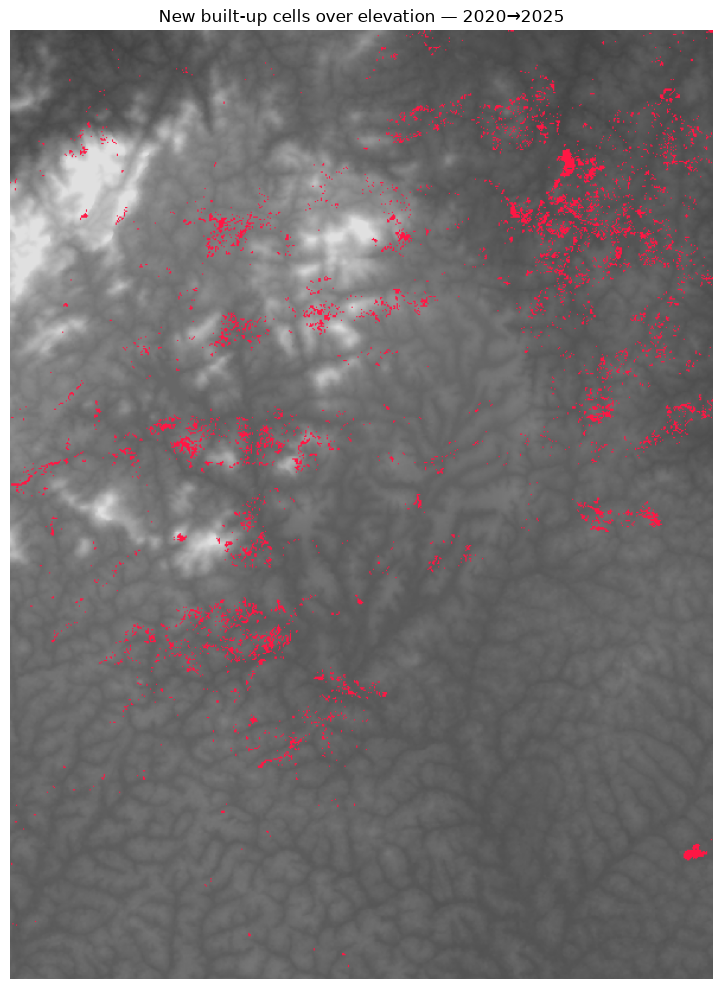

In [ ]:
if EE_READY:
    latest_start = CONFIG["mapping"]["epochs"][-2]
    latest_end = CONFIG["mapping"]["epochs"][-1]

    transition = ee.Image(
        manifest_asset(
            "transition",
            period_start=int(latest_start),
            period_end=int(latest_end),
        )
    ).select("target_transition_5y")

    terrain = ee.Image(
        CONFIG["inputs"]["terrain_asset"]
    ).select("elevation_m")

    overlay = terrain.visualize(
        min=500,
        max=1100,
        palette=["202020", "e0e0e0"],
    ).blend(
        transition.selfMask().visualize(
            palette=["ff1744"],
        )
    )

    overlay_thumbnail = ee_thumbnail(
        overlay,
        {},
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(overlay_thumbnail)
    ax.set_title(
        f"New built-up cells over elevation — "
        f"{latest_start}→{latest_end}"
    )
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "20_terrain_expansion_overlay.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

## 13. Interactive Earth Engine map

The Folium map provides switchable layers for the five built-up states and
four transitions. It is intended for local exploration and supervisor
demonstration.

In [42]:
def add_ee_layer(
    map_object: Any,
    image: Any,
    visualization: dict[str, Any],
    name: str,
    shown: bool = False,
) -> None:
    """Add an Earth Engine tile layer to a Folium map."""
    map_id = ee.Image(image).getMapId(visualization)
    folium.raster_layers.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True,
        show=shown,
    ).add_to(map_object)


if EE_READY and OPTIONAL_IMPORTS["folium"]:
    interactive_map = folium.Map(
        location=[3.87, 11.52],
        zoom_start=11,
        tiles="CartoDB positron",
    )

    for epoch in CONFIG["mapping"]["epochs"]:
        state = ee.Image(
            manifest_asset("state", epoch=int(epoch))
        ).select("built_state_final")
        add_ee_layer(
            interactive_map,
            state.selfMask(),
            {"palette": ["e53935"]},
            f"Built-up {epoch}",
            shown=(epoch == max(CONFIG["mapping"]["epochs"])),
        )

    for start, end in zip(
        CONFIG["mapping"]["epochs"][:-1],
        CONFIG["mapping"]["epochs"][1:],
    ):
        transition = ee.Image(
            manifest_asset(
                "transition",
                period_start=int(start),
                period_end=int(end),
            )
        ).select("target_transition_5y")
        add_ee_layer(
            interactive_map,
            transition.selfMask(),
            {"palette": ["ff9800"]},
            f"New built {start}→{end}",
            shown=False,
        )

    folium.LayerControl(collapsed=False).add_to(interactive_map)
    interactive_map
else:
    print(
        "Folium or Earth Engine is unavailable; "
        "the interactive map was skipped."
    )

## 14. Interactive time slider

This lightweight widget switches between static Earth Engine thumbnails. It
does not create a standalone dashboard and does not modify the dataset.

In [43]:
if EE_READY and OPTIONAL_IMPORTS["ipywidgets"]:
    state_images = {
        int(epoch): ee.Image(
            manifest_asset("state", epoch=int(epoch))
        ).select("built_state_final")
        for epoch in CONFIG["mapping"]["epochs"]
    }

    year_slider = widgets.SelectionSlider(
        options=CONFIG["mapping"]["epochs"],
        value=max(CONFIG["mapping"]["epochs"]),
        description="Epoch:",
        continuous_update=False,
    )
    output = widgets.Output()

    def update_state_map(change: dict[str, Any]) -> None:
        with output:
            clear_output(wait=True)
            epoch = int(change["new"])
            thumbnail = ee_thumbnail(
                state_images[epoch],
                {
                    "min": 0,
                    "max": 1,
                    "palette": ["111111", "e53935"],
                },
                dimensions=700,
            )
            plt.figure(figsize=(8, 8))
            plt.imshow(thumbnail)
            plt.title(f"Final built-up state — {epoch}")
            plt.axis("off")
            plt.show()

    year_slider.observe(update_state_map, names="value")
    display(year_slider, output)
    update_state_map({"new": year_slider.value})
else:
    print(
        "Earth Engine or ipywidgets is unavailable; "
        "the time slider was skipped."
    )

SelectionSlider(continuous_update=False, description='Epoch:', index=5, options=(2000, 2005, 2010, 2015, 2020,…

Output()

## 15. Candidate-method diagnostic appendix

When the original candidate gallery is present, it is displayed as supporting
evidence for the provisional selection of NDBI. It is not part of the final
cell-time dataset.

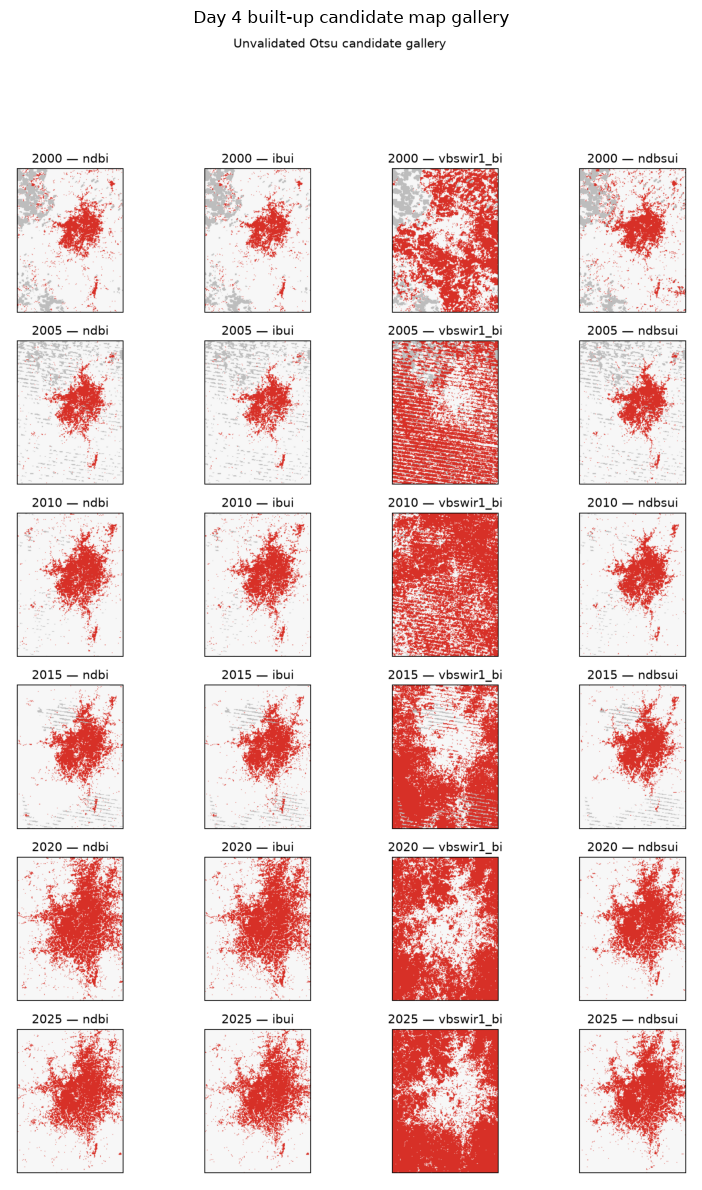

In [44]:
if PATHS["candidate_gallery"].is_file():
    candidate_image = plt.imread(PATHS["candidate_gallery"])
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.imshow(candidate_image)
    ax.set_title("Day 4 built-up candidate map gallery")
    ax.axis("off")
    fig.tight_layout()
    plt.show()
else:
    print("The candidate map gallery is unavailable.")

## 16. Automated exploratory report

The final cell writes a concise Markdown report that links the saved figures
and records the principal Version 1 statistics. The report is generated from
the released files, not from hard-coded values.

In [45]:
def format_number(value: float | int) -> str:
    """Format one numerical value for the Markdown report."""
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    return f"{float(value):,.3f}"


report_lines = [
    "# Yaoundé Urban Expansion Dataset V1 — Exploratory Report",
    "",
    "## Release",
    "",
    f"- Dataset: `{CONFIG['release']['dataset_id']}`",
    f"- Version: `{CONFIG['release']['semantic_version']}`",
    f"- Release status: `{CONFIG['release']['release_status']}`",
    (
        "- Mapping selection status: "
        f"`{CONFIG['release']['mapping_selection_status']}`"
    ),
    f"- Mapping method: `{CONFIG['mapping']['selected_index'].upper()}`",
    "",
    "## Dataset scale",
    "",
    f"- Cell-time rows: {len(cell_time):,}",
    f"- Unique cells: {cell_time['cell_id'].nunique():,}",
    f"- Five-year transitions: {len(demand)}",
    f"- Tracking epochs: {len(metrics)}",
    "",
    "## Transition summary",
    "",
    "| Transition | Eligible cells | Converted cells | "
    "New built-up area (ha) | Pairwise support (%) |",
    "|---|---:|---:|---:|---:|",
]

demand_lookup = demand.assign(
    transition_id=(
        demand["period_start"].astype(str)
        + "_"
        + demand["period_end"].astype(str)
    )
).set_index("transition_id")

for row in transition_overview.itertuples(index=False):
    demand_row = demand_lookup.loc[str(row.transition_id)]
    report_lines.append(
        f"| {row.transition_id} | "
        f"{int(row.eligible_cells):,} | "
        f"{int(row.converted_cells):,} | "
        f"{float(demand_row.observed_new_built_area_ha):,.2f} | "
        f"{float(demand_row.common_valid_pct_of_core):,.2f} |"
    )

report_lines.extend(
    [
        "",
        "## Tracking summary",
        "",
        "| Epoch | Built area (ha) | PBA | NUMP | MPS (ha) |",
        "|---:|---:|---:|---:|---:|",
    ]
)

for row in metrics.itertuples(index=False):
    report_lines.append(
        f"| {int(row.epoch)} | "
        f"{float(row.built_area_ha):,.2f} | "
        f"{float(row.pba):.4f} | "
        f"{int(row.nump):,} | "
        f"{float(row.mps_ha):,.4f} |"
    )

report_lines.extend(
    [
        "",
        "## Figures",
        "",
    ]
)

for figure_path in sorted(FIGURE_DIR.glob("*.png")):
    relative = figure_path.relative_to(REPORT_DIR)
    report_lines.extend(
        [
            f"### {figure_path.stem.replace('_', ' ').title()}",
            "",
            f"![{figure_path.stem}]({relative.as_posix()})",
            "",
        ]
    )

report_lines.extend(
    [
        "## Interpretation limits",
        "",
        "- NDBI remains provisional pending expert manual validation.",
        (
            "- The cell-time dataset contains eligible non-built cells, "
            "not all cells in the city."
        ),
        (
            "- Historical demand is measured on pairwise common-valid "
            "spatial support."
        ),
        (
            "- Tracking metrics are measured on the fixed all-epoch "
            "common support."
        ),
        (
            "- Exploratory feature importance is not a causal analysis "
            "and is not the final forecasting model."
        ),
    ]
)

report_path = REPORT_DIR / "exploratory_report.md"
report_path.write_text(
    "\n".join(report_lines) + "\n",
    encoding="utf-8",
)

print(f"Report written to: {report_path}")
print(f"Figures written to: {FIGURE_DIR}")

Report written to: /Users/omer/Documents/MIORPA/Pending.../SprawlGP/reports/exploration_v2/exploratory_report.md
Figures written to: /Users/omer/Documents/MIORPA/Pending.../SprawlGP/reports/exploration_v2/figures


## 17. Export the executed notebook to HTML

After running all cells, create a self-contained HTML report from the
repository root:

```bash
jupyter nbconvert   --to html   --execute notebooks/07_explore_final_dataset_v1.ipynb   --output-dir reports/exploration_v1
```

The Markdown report generated by the preceding cell is available at:

```text
reports/exploration_v1/exploratory_report.md
```

The interactive Folium and Plotly outputs are preserved in the executed HTML
notebook.